In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("final_risk_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Risk_Level
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,Low
1,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza,Low
2,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke,High
3,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease,High
4,6,49,Male,"vomiting, swelling, dizziness, fatigue",4,Heart Disease,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21566 entries, 0 to 21565
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     21566 non-null  int64 
 1   Age            21566 non-null  int64 
 2   Gender         21566 non-null  object
 3   Symptoms       21566 non-null  object
 4   Symptom_Count  21566 non-null  int64 
 5   Disease        21566 non-null  object
 6   Risk_Level     21566 non-null  object
dtypes: int64(3), object(4)
memory usage: 1.2+ MB


In [6]:
df.isna().sum()

Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
Risk_Level       0
dtype: int64

In [7]:
df["Risk_Level"].value_counts()

Risk_Level
Low     19972
High     1594
Name: count, dtype: int64

In [9]:
df["Risk_Label"] = df["Risk_Level"].map({"Low": 0, "High": 1})

In [10]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Risk_Level,Risk_Label
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,Low,0
1,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza,Low,0
2,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke,High,1
3,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease,High,1
4,6,49,Male,"vomiting, swelling, dizziness, fatigue",4,Heart Disease,High,1


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["Symptoms"])

y = df["Risk_Label"]

print(X.shape)

(21566, 33)


In [12]:
from imblearn.over_sampling import SMOTE

In [13]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
Risk_Label
0    19972
1     1594
Name: count, dtype: int64

After SMOTE:
Risk_Label
0    19972
1    19972
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, 
    y_resampled, 
    test_size=0.2, 
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (31955, 33)
Testing size: (7989, 33)


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5462510952559769

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.54      0.55      4026
           1       0.54      0.55      0.55      3963

    accuracy                           0.55      7989
   macro avg       0.55      0.55      0.55      7989
weighted avg       0.55      0.55      0.55      7989



In [17]:
from sklearn.model_selection import train_test_split

# Features
X = df[["Symptoms", "Age", "Gender", "Symptom_Count", "Disease"]]

# Target
y = df["Risk_Label"]

# Stratify يحافظ على نسبة High/Low في التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Test label distribution:\n", y_test.value_counts())

Train: (17252, 5) Test: (4314, 5)
Train label distribution:
 Risk_Label
0    15977
1     1275
Name: count, dtype: int64
Test label distribution:
 Risk_Label
0    3995
1     319
Name: count, dtype: int64


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# تحديد الأعمدة
text_features = "Symptoms"
numeric_features = ["Age", "Symptom_Count"]
categorical_features = ["Gender", "Disease"]

# تحويل الأعمدة
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=2000), text_features),
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# إنشاء Pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# تدريب
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       1.00      1.00      1.00       319

    accuracy                           1.00      4314
   macro avg       1.00      1.00      1.00      4314
weighted avg       1.00      1.00      1.00      4314

ROC-AUC Score: 1.0

Confusion Matrix:
[[3995    0]
 [   0  319]]


In [20]:
from sklearn.model_selection import train_test_split

X_text = df["Symptoms"]
y = df["Risk_Label"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model_text = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=2000)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_text.fit(X_train_text, y_train_text)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_text = model_text.predict(X_test_text)
y_proba_text = model_text.predict_proba(X_test_text)[:,1]

print("Classification Report:\n")
print(classification_report(y_test_text, y_pred_text))

print("ROC-AUC Score:", roc_auc_score(y_test_text, y_proba_text))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_text))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.62      0.74      3995
           1       0.08      0.40      0.13       319

    accuracy                           0.60      4314
   macro avg       0.50      0.51      0.44      4314
weighted avg       0.87      0.60      0.70      4314

ROC-AUC Score: 0.49089143561112836

Confusion Matrix:
[[2473 1522]
 [ 192  127]]


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# نحدد X و y
X = df[["Symptoms", "Age", "Gender", "Disease"]]
y = df["Risk_Label"]

# تقسيم مع stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# تحديد الأعمدة
text_feature = "Symptoms"
numeric_features = ["Age"]
categorical_features = ["Gender", "Disease"]

# المعالجة
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=2000), text_feature),
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# بناء الموديل
model_strong = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# تدريب
model_strong.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred = model_strong.predict(X_test)
y_proba = model_strong.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       1.00      1.00      1.00       319

    accuracy                           1.00      4314
   macro avg       1.00      1.00      1.00      4314
weighted avg       1.00      1.00      1.00      4314

ROC-AUC Score: 1.0

Confusion Matrix:
[[3995    0]
 [   0  319]]


In [24]:
X = df[["Symptoms", "Age", "Gender"]]
y = df["Risk_Label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=2000), "Symptoms"),
        ("num", "passthrough", ["Age"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Gender"])
    ]
)

model_clean = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_clean.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred = model_clean.predict(X_test)
y_proba = model_clean.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6001390820584145

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.62      0.74      3995
           1       0.07      0.39      0.12       319

    accuracy                           0.60      4314
   macro avg       0.50      0.50      0.43      4314
weighted avg       0.86      0.60      0.70      4314

ROC-AUC Score: 0.4898387875126039

Confusion Matrix:
[[2466 1529]
 [ 196  123]]


In [26]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X_counts = vectorizer.fit_transform(df["Symptoms"])

import pandas as pd

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "frequency": X_counts.toarray().sum(axis=0)
})

word_freq = word_freq.sort_values(by="frequency", ascending=False)

word_freq.head(20)

,word,frequency
20,pain,19175
16,loss,7839
32,weight,7716
2,appetite,3952
1,anxiety,3917
17,muscle,3910
24,sneezing,3909
13,headache,3908
27,swelling,3905
3,blurred,3895


In [27]:
high_risk_keywords = [
    "chest",
    "shortness",
    "blurred",
    "swelling",
    "vomiting",
    "dizziness",
    "severe",
    "fever"
]

def calculate_risk_score(text):
    score = 0
    for word in high_risk_keywords:
        if word in text.lower():
            score += 1
    return score

df["Risk_Score"] = df["Symptoms"].apply(calculate_risk_score)

df[["Symptoms", "Risk_Score"]].head(10)

,Symptoms,Risk_Score
0,"fever, back pain, shortness of breath",2
1,"sore throat, vomiting, diarrhea",1
2,"blurred vision, depression, weight loss, muscl...",1
3,"swelling, appetite loss, nausea",1
4,"vomiting, swelling, dizziness, fatigue",3
5,"anxiety, shortness of breath, appetite loss, c...",1
6,"sore throat, weight loss, chest pain, depressi...",1
7,"insomnia, diarrhea, swelling",1
8,"joint pain, shortness of breath, runny nose",1
9,"vomiting, insomnia, shortness of breath, blurr...",3


In [28]:
risk_weights = {
    "chest pain": 2,
    "shortness of breath": 2,
    "blurred vision": 2,
    "dizziness": 1,
    "fever": 1,
    "vomiting": 1,
    "swelling": 1
}

def calculate_weighted_risk(text):
    score = 0
    text = text.lower()
    for symptom, weight in risk_weights.items():
        if symptom in text:
            score += weight
    return score

df["Weighted_Risk_Score"] = df["Symptoms"].apply(calculate_weighted_risk)

df[["Symptoms", "Weighted_Risk_Score"]].head(10)

,Symptoms,Weighted_Risk_Score
0,"fever, back pain, shortness of breath",3
1,"sore throat, vomiting, diarrhea",1
2,"blurred vision, depression, weight loss, muscl...",2
3,"swelling, appetite loss, nausea",1
4,"vomiting, swelling, dizziness, fatigue",3
5,"anxiety, shortness of breath, appetite loss, c...",2
6,"sore throat, weight loss, chest pain, depressi...",2
7,"insomnia, diarrhea, swelling",1
8,"joint pain, shortness of breath, runny nose",2
9,"vomiting, insomnia, shortness of breath, blurr...",5


In [29]:
def risk_level(score):
    if score <= 1:
        return "Low"
    elif score <= 3:
        return "Medium"
    else:
        return "High"

df["Predicted_Risk_Level"] = df["Weighted_Risk_Score"].apply(risk_level)

df[["Symptoms", "Weighted_Risk_Score", "Predicted_Risk_Level"]].head(10)

,Symptoms,Weighted_Risk_Score,Predicted_Risk_Level
0,"fever, back pain, shortness of breath",3,Medium
1,"sore throat, vomiting, diarrhea",1,Low
2,"blurred vision, depression, weight loss, muscl...",2,Medium
3,"swelling, appetite loss, nausea",1,Low
4,"vomiting, swelling, dizziness, fatigue",3,Medium
5,"anxiety, shortness of breath, appetite loss, c...",2,Medium
6,"sore throat, weight loss, chest pain, depressi...",2,Medium
7,"insomnia, diarrhea, swelling",1,Low
8,"joint pain, shortness of breath, runny nose",2,Medium
9,"vomiting, insomnia, shortness of breath, blurr...",5,High


In [30]:
df["Predicted_Risk_Level"].value_counts()

Predicted_Risk_Level
Low       9973
Medium    8908
High      2685
Name: count, dtype: int64

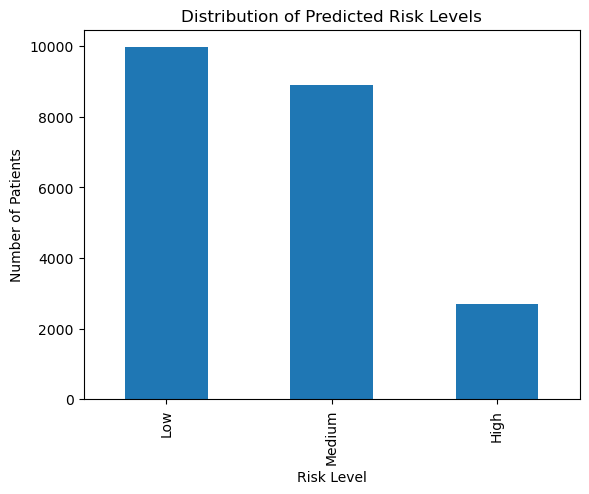

In [32]:
import matplotlib.pyplot as plt

df["Predicted_Risk_Level"].value_counts().plot(kind="bar")
plt.title("Distribution of Predicted Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()

In [34]:
import pandas as pd
from prophet import Prophet


df_forecast = pd.read_csv("healthcare_analytics_patient_flow_data.csv")


df_forecast["Patient Admission Date"] = pd.to_datetime(
    df_forecast["Patient Admission Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)


admissions_only = df_forecast[df_forecast["Patient Admission Flag"] == "Admission"]


daily_admissions = (
    admissions_only
    .groupby("Patient Admission Date")
    .size()
    .reset_index(name="Total_Admissions")
    .sort_values("Patient Admission Date")
)


prophet_df = daily_admissions.rename(
    columns={
        "Patient Admission Date": "ds",
        "Total_Admissions": "y"
    }
)


model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

print("every thing is back")

22:23:52 - cmdstanpy - INFO - Chain [1] start processing
22:23:52 - cmdstanpy - INFO - Chain [1] done processing


every thing is back


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


merged = prophet_df.merge(forecast[["ds", "yhat"]], on="ds", how="inner")

mae = mean_absolute_error(merged["y"], merged["yhat"])
rmse = np.sqrt(mean_squared_error(merged["y"], merged["yhat"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.1249552333539725
RMSE: 2.653933781791566


In [36]:


merged = merged.sort_values("ds")

merged["naive_pred"] = merged["y"].shift(1)


naive_data = merged.dropna()

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(naive_data["y"], naive_data["naive_pred"])
rmse_naive = np.sqrt(mean_squared_error(naive_data["y"], naive_data["naive_pred"]))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 2.991349480968858
Naive RMSE: 3.7303116375840246
